# Data Exploration: Skin Lesion Segmentation

This notebook explores the ISIC 2018 dataset and visualizes sample images with their corresponding segmentation masks.

In [5]:
import sys
import os

# Add src directory to path
sys.path.insert(0, os.path.join(os.getcwd(), 'src'))

import torch
import matplotlib.pyplot as plt
from dataset import SegmentationDatasets
from utils import show_samples

In [2]:
# Set up data paths
base_dir = os.path.join(os.getcwd(), '../../')
train_image_dir = os.path.join(base_dir, 'train/images')
train_mask_dir = os.path.join(base_dir, 'train/masks')
val_image_dir = os.path.join(base_dir, 'val/images')
val_mask_dir = os.path.join(base_dir, 'val/masks')

print(f"Training images: {train_image_dir}")
print(f"Training masks: {train_mask_dir}")
print(f"Validation images: {val_image_dir}")
print(f"Validation masks: {val_mask_dir}")

Training images: c:\Users\deafv\Documents\Projects\Undergraduate\CSCI425\deep-learning-skin-lesion-segmentation\data\models\notebooks\../../train/images
Training masks: c:\Users\deafv\Documents\Projects\Undergraduate\CSCI425\deep-learning-skin-lesion-segmentation\data\models\notebooks\../../train/masks
Validation images: c:\Users\deafv\Documents\Projects\Undergraduate\CSCI425\deep-learning-skin-lesion-segmentation\data\models\notebooks\../../val/images
Validation masks: c:\Users\deafv\Documents\Projects\Undergraduate\CSCI425\deep-learning-skin-lesion-segmentation\data\models\notebooks\../../val/masks


In [3]:
# Load training dataset without transforms to view original data
train_dataset = SegmentationDatasets(
    image_dir=train_image_dir,
    mask_dir=train_mask_dir,
    transform=None
)

print(f"Training dataset size: {len(train_dataset)}")
print(f"Sample image shape: {train_dataset[0][0].shape}")
print(f"Sample mask shape: {train_dataset[0][1].shape}")

Training dataset size: 2594
Sample image shape: (767, 1022, 3)
Sample mask shape: (767, 1022)


## Sample Images and Masks Visualization

Below are sample images from the training dataset with their corresponding segmentation masks:

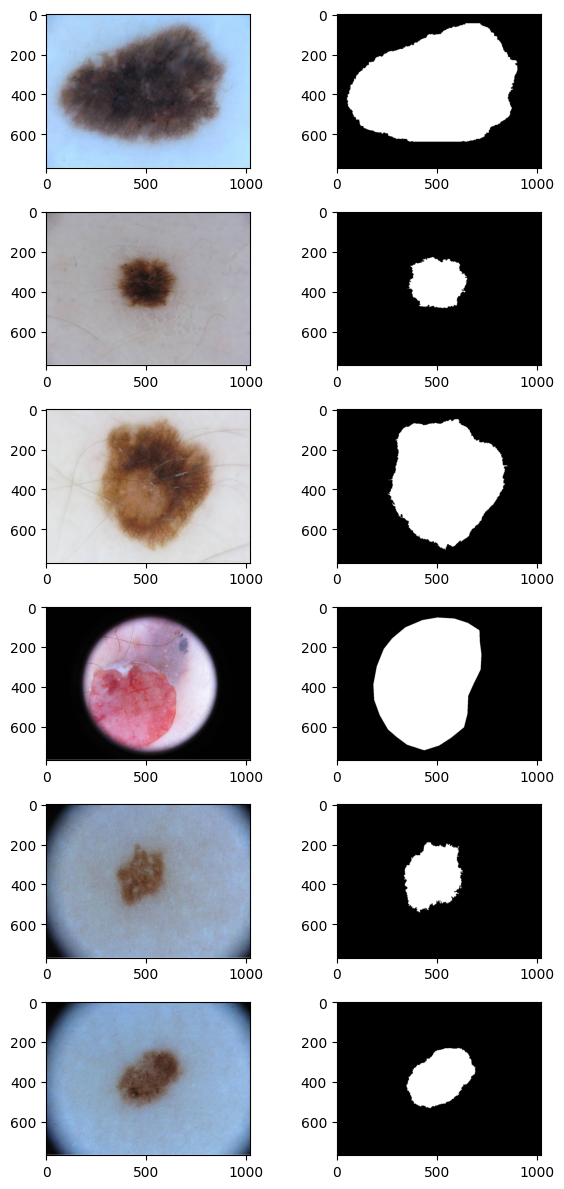

In [4]:
# Visualize sample images and masks from the training dataset
show_samples(train_dataset, n=6)

## Model Architecture: U-Net with ResNet-34 Encoder

Load a pretrained U-Net model using segmentation-models-pytorch library. The encoder uses ResNet-34 pretrained on ImageNet for transfer learning.

In [6]:
import segmentation_models_pytorch as smp

# Load pretrained U-Net with ResNet-34 encoder
model = smp.Unet(
    encoder_name='resnet34',
    encoder_weights='imagenet',  # Use ImageNet pretrained weights
    in_channels=3,                # RGB images
    classes=1                     # Binary segmentation (lesion vs non-lesion)
)

print(f"Model loaded successfully!")
print(f"Model type: {type(model)}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

c:\Users\deafv\miniconda3\envs\asl-mlp-cs425\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\deafv\.cache\huggingface\hub\models--smp-hub--resnet34.imagenet. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Model loaded successfully!
Model type: <class 'segmentation_models_pytorch.decoders.unet.model.Unet'>
Model parameters: 24,436,369
Trainable parameters: 24,436,369
